In [17]:
from prody import *
p = parsePDB('1crn')
gnm = GNM()
calphas = p.select('calpha')
calphas

@> Connecting wwPDB FTP server RCSB PDB (USA).
@> Downloading PDB files via FTP failed, trying HTTP.
@> 1crn downloaded (1crn.pdb.gz)
@> PDB download via HTTP completed (1 downloaded, 0 failed).
@> 327 atoms and 1 coordinate set(s) were parsed in 0.00s.


<Selection: 'calpha' from 1crn (46 atoms)>

In [18]:
gnm.buildKirchhoff(calphas, cutoff=7.0)


@> Kirchhoff was built in 0.00s.


In [19]:
gnm.getKirchhoff()

array([[ 7., -1., -1., ...,  0.,  0.,  0.],
       [-1.,  7., -1., ...,  0.,  0.,  0.],
       [-1., -1., 11., ..., -1., -1., -1.],
       ...,
       [ 0.,  0., -1., ...,  9., -1., -1.],
       [ 0.,  0., -1., ..., -1.,  9., -1.],
       [ 0.,  0., -1., ..., -1., -1.,  8.]])

In [20]:
gnm.getGamma()

1.0

In [21]:
gnm.calcModes()

@> 20 modes were calculated in 0.00s.


In [58]:
B = calcTempFactors(gnm, calphas)
B

array([ 6.27232559,  4.31210122,  2.08206651,  1.35136469,  1.97876676,
        4.04746512,  7.48048775,  7.19960993,  1.34512247,  1.93981899,
        3.35300018,  2.79577583,  2.39232752,  3.59845452,  4.61089206,
        3.43182585,  3.59635575,  8.98555067, 10.82453476, 11.21968932,
        4.57463666,  8.95242021,  8.55933342,  8.35081589,  3.97666415,
        2.32011912,  2.33164754,  3.22910429,  6.88950534,  2.06042668,
        2.10326853,  1.7579062 ,  2.89223429,  7.94702919,  9.83669466,
       12.61130522, 12.89505859, 12.24404084, 14.27949427,  5.7442866 ,
        8.93773902, 11.38525622, 10.62350216,  3.36661535,  3.36661535,
        3.29674471])

In [57]:
import numpy as np

W = gnm.getEigvals()
W = np.diag(1/W)
V = gnm.getEigvecs()
sqf = np.dot(V * V, W).sum(axis=1)

expBetas = calphas.getBetas()
B = sqf * (expBetas.sum() / sqf.sum())
B

array([ 6.27232559,  4.31210122,  2.08206651,  1.35136469,  1.97876676,
        4.04746512,  7.48048775,  7.19960993,  1.34512247,  1.93981899,
        3.35300018,  2.79577583,  2.39232752,  3.59845452,  4.61089206,
        3.43182585,  3.59635575,  8.98555067, 10.82453476, 11.21968932,
        4.57463666,  8.95242021,  8.55933342,  8.35081589,  3.97666415,
        2.32011912,  2.33164754,  3.22910429,  6.88950534,  2.06042668,
        2.10326853,  1.7579062 ,  2.89223429,  7.94702919,  9.83669466,
       12.61130522, 12.89505859, 12.24404084, 14.27949427,  5.7442866 ,
        8.93773902, 11.38525622, 10.62350216,  3.36661535,  3.36661535,
        3.29674471])

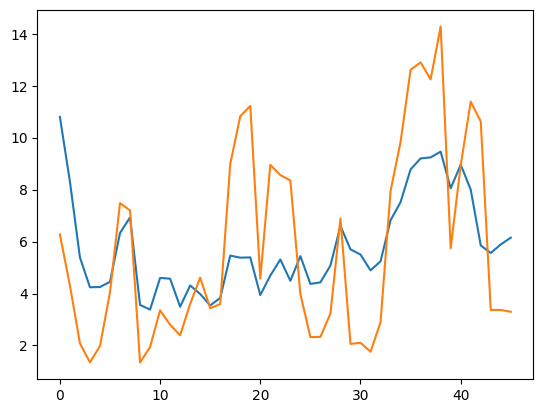

In [59]:
import matplotlib.pyplot as plt


# Create the plot
plt.plot(range(46), calphas.getBetas())
plt.plot(range(46), B)

# Display the plot
plt.show()


@> Connecting wwPDB FTP server RCSB PDB (USA).
@> Downloading PDB files via FTP failed, trying HTTP.
@> 1a6m downloaded (1a6m.pdb.gz)
@> PDB download via HTTP completed (1 downloaded, 0 failed).
@> 1445 atoms and 1 coordinate set(s) were parsed in 0.03s.
@> Kirchhoff was built in 0.00s.
@> 20 modes were calculated in 0.06s.


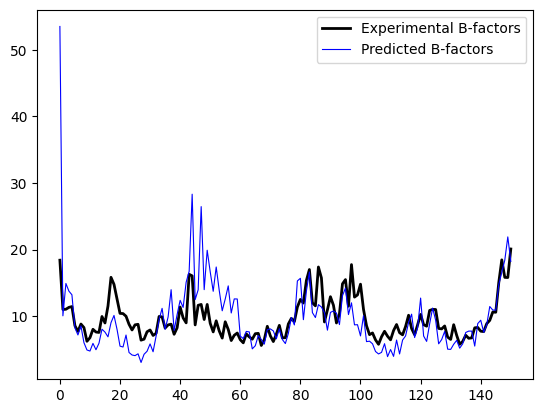

In [ ]:
# Check 2011 - LWY - Models with Energy Penalty on Interresidue Rotation Address Insufficiencies of Conventional Elastic Network Models

p = parsePDB('1a6m')
gnm = GNM()
gnm.buildKirchhoff(calphas, cutoff=7.5)
gnm.calcModes()

calphas = p.select('protein and name CA')
nCAs = len(calphas)
B = calcTempFactors(gnm, calphas)

# Create the plot
plt.plot(range(nCAs), calphas.getBetas(), label='Experimental B-factors', color='black', linewidth=2)
plt.plot(range(nCAs), B, label='Predicted B-factors', color='blue', linewidth=0.8)
plt.legend()
# Display the plot
plt.show()
